In [1]:
import pandas as pd
import numpy as np
import os
import time
import pickle
import itertools
import seaborn as sns
from itertools import combinations
import umap
from matplotlib import pyplot as plt

#%run s7_0_functions_for_data_preprocessing_for_ml.ipynb
os.environ["NUMBA_WARNINGS"] = "1"

os.chdir(os.getcwd())
os.getcwd()
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=DeprecationWarning)

from itables import init_notebook_mode
init_notebook_mode(connected=True,all_interactive=True)

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Functions and parameters

In [2]:
parameters_for_analysis={'tb21_22_2416_pats_27_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':27,
                            'training_days':120},

                        'tb21_1268_pats_43_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':43,
                            'training_days':120},
                         
                         'tb21_1240_pats_43_vars_unfavour_cat_at_18_months':{
                            'result_cat':'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':43,
                            'training_days':120},
                        
                         'tb21_1258_pats_42_vars_result_at_12_months':{
                            'result_cat':'RESULT_AT_12_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':42,
                            'training_days':120},
                        }

#### =======================
### LOAD COMMON VARIABLES AND PATIENTS FOR THE GIVEN OUTPUT LABEL CATEGORY, CREATED IN S7_2_....IPNYB NOTEBOOK
def return_common_vars_pats_for_anal(result_cat,selection_method,num_of_common_vars,clust_comb,graph_metric): 

    ## Select the common variables and common patients
    if 'clustering' in selection_method:
        if selection_method=='patient_clustering':
            fname='pat_clust_common_vars.pickle'
        if selection_method=='var_clustering':
            fname='var_clust_common_vars.pickle'
        
        ## Use patients graphs to extract common patients and variables
        fn=os.path.join('../data/',fname)
        with open(fn, 'rb') as f:
            common_vars=pickle.load(f)
        
        common_variables_for_analysis=common_vars[result_cat][clust_comb][num_of_common_vars]['common_variables']+['USUBJID','DAY']
        pats_for_analysis=common_vars[result_cat][clust_comb][num_of_common_vars]['patients']
    
    if 'graph' in selection_method:
        if selection_method=='patient_graph':
            fname='pat_gr_common_dict.pickle'
        
        if selection_method=='variable_graph':
            fname='var_gr_common_dict.pickle'  

        ## Use patients graphs to extract common patients and variables
        fn=os.path.join('../data/',fname)
        with open(fn, 'rb') as f:
            gr_common_dict=pickle.load(f)
        num_of_pats=[*gr_common_dict[result_cat][clust_comb][graph_metric][num_of_common_vars]][0]
        common_variables_for_analysis=gr_common_dict[clust_comb][graph_metric][num_of_common_vars][num_of_pats]['common_vars']+['USUBJID','DAY']
        common_variables_for_analysis=list(set(common_variables_for_analysis))
        pats_for_analysis=gr_common_dict[clust_comb][graph_metric][num_of_common_vars][num_of_pats]['common_pats']
  
    return common_variables_for_analysis,pats_for_analysis


## Plot labels to predict and the available number of patients

In [17]:
outcome_df.loc[(~outcome_df[result_cat].isna())&(outcome_df.index.isin(pats_with_outcome)),result_cat].value_counts(dropna=False)

RESULT_AT_18_MONTHS
FAVOURABLE      1987
UNFAVOURABLE     429
Name: count, dtype: int64

selection method:  tb21_22_2416_pats_27_vars_result_at_18_months


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


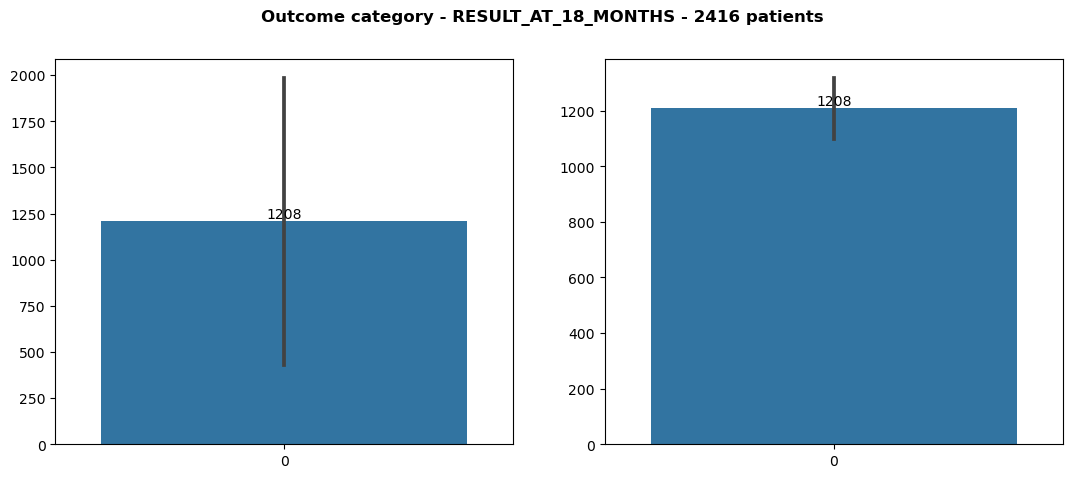

In [16]:

### Load common variables and patient IDs with those variables
imputation=False

common_vars={}
common_pats={}

for key in [*parameters_for_analysis][:1]:
    parameter_dict=parameters_for_analysis[key]
    result_cat=parameter_dict['result_cat']
    selection_method=parameter_dict['selection_method']
    clust_comb=parameter_dict['clust_comb']
    num_of_common_vars=parameter_dict['num_of_common_vars']
    graph_metric=parameter_dict['graph_metric']
    training_days=parameter_dict['training_days']
    data_to_subset='days_with_lab_measurements_only'


    print('selection method: ',key)
    common_variables_for_analysis,pats_for_analysis = return_common_vars_pats_for_anal(result_cat,selection_method,
                                                                                      num_of_common_vars,clust_comb,
                                                                                      graph_metric)

    common_vars[result_cat]=common_variables_for_analysis
    common_pats[result_cat]=pats_for_analysis
    
    ## Load dataset
    if imputation==False:
        fn='../data/'+key+'_preproc_data_wo_imp.csv.gz'
    if imputation==True:
        fn='../data/'+key+'_preproc_data_with_imp.csv.gz'
        
    data=pd.read_csv(fn,low_memory=False)   


    ## PLot labels and number of patients available with that label
    pats_with_outcome=outcome_df.loc[(~outcome_df[result_cat].isna()),:].index.tolist()
    pats_with_outcome=list(set(pats_with_outcome)&set(data['USUBJID'].tolist()))

    fig,ax=plt.subplots(1,2,figsize=(13,5))
    fig.suptitle(f'Outcome category - {result_cat} - {len(pats_with_outcome)} patients',fontweight='bold',fontsize=12)
    sns.barplot(outcome_df.loc[(~outcome_df[result_cat].isna())&(outcome_df.index.isin(pats_with_outcome)),result_cat].value_counts(dropna=False),ax=ax[0])
    sns.barplot(outcome_df.loc[(~outcome_df[result_cat].isna())&(outcome_df.index.isin(pats_with_outcome)),'STUDYID'].value_counts(dropna=False),ax=ax[1])
    for aa in ax.flatten():
        for bars in aa.containers:
            aa.bar_label(bars,fontsize=10)

## Plot number of patients per Phase 3 study

In [18]:
outcome_df

RESULT_AT_18_MONTHS  \
USUBJID                               
TB-1020/1016                    NaN   
TB-1020/1023                    NaN   
TB-1020/1029                    NaN   
TB-1020/1031                    NaN   
TB-1020/1039                    NaN   
...                             ...   
TB-1018/04-9011                 NaN   
TB-1018/04-9010                 NaN   
TB-1018/02-9066                 NaN   
TB-1018/02-9046                 NaN   
TB-1018/02-9053                 NaN   

                UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS  STUDYID  \
USUBJID                                                               
TB-1020/1016                                           NaN  TB-1020   
TB-1020/1023                                           NaN  TB-1020   
TB-1020/1029                                           NaN  TB-1020   
TB-1020/1031                        INITIAL HRM RESISTANCE  TB-1020   
TB-1020/1039                                           NaN  TB-1020   
...                                                    ...      ...   
TB-1018/04-9011                                        NaN  TB-1018   
TB-1018/04-9010                                        NaN  TB-1018   
TB-1018/02-9066                                        NaN  TB-1018   
TB-1018/02-9046                                        NaN  TB-1018   
TB-1018/02-9053                                        NaN  TB-1018   

                RESULT_AT_END_OF_TREATMENT RESULT_AT_12_MONTHS  \
USUBJID                                                          
TB-1020/1016                           NaN                 NaN   
TB-1020/1023                           NaN                 NaN   
TB-1020/1029                           NaN                 NaN   
TB-1020/1031                           NaN                 NaN   
TB-1020/1039                           NaN                 NaN   
...                                    ...                 ...   
TB-1018/04-9011                 FAVOURABLE                 NaN   
TB-1018/04-9010                 FAVOURABLE                 NaN   
TB-1018/02-9066                 FAVOURABLE                 NaN   
TB-1018/02-9046                 FAVOURABLE                 NaN   
TB-1018/02-9053                 FAVOURABLE                 NaN   

                RESULT_LIQUID_MEDIUM_AT_18_MONTHS RESULT_AT_24_MONTHS  \
USUBJID                                                                 
TB-1020/1016                                  NaN                 NaN   
TB-1020/1023                                  NaN                 NaN   
TB-1020/1029                                  NaN                 NaN   
TB-1020/1031                                  NaN                 NaN   
TB-1020/1039                                  NaN                 NaN   
...                                           ...                 ...   
TB-1018/04-9011                               NaN                 NaN   
TB-1018/04-9010                               NaN                 NaN   
TB-1018/02-9066                               NaN                 NaN   
TB-1018/02-9046                               NaN                 NaN   
TB-1018/02-9053                               NaN                 NaN   

                UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS  \
USUBJID                                                      
TB-1020/1016                                           NaN   
TB-1020/1023                                           NaN   
TB-1020/1029                                           NaN   
TB-1020/1031                                           NaN   
TB-1020/1039                                           NaN   
...                                                    ...   
TB-1018/04-9011                                        NaN   
TB-1018/04-9010                                        NaN   
TB-1018/02-9066                                        NaN   
TB-1018/02-9046                                        NaN   
TB-1018/02-9053                

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


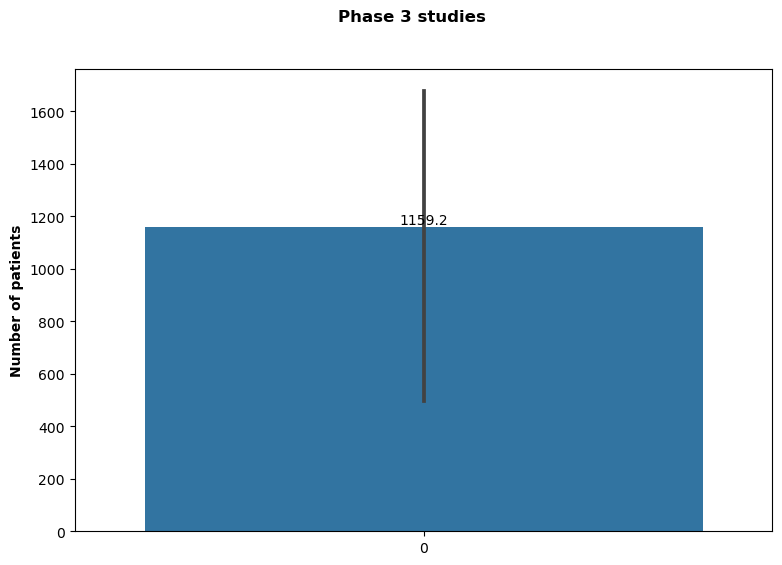

In [11]:
## Load outcome dataframe
outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

fig,ax=plt.subplots(1,1,figsize=(9,6))
fig.suptitle('Phase 3 studies',fontweight='bold')
sns.barplot(outcome_df.groupby('STUDYID').apply(lambda x: len(x.index)),ax=ax)
ax.set_ylabel('Number of patients',fontweight='bold')
ax.tick_params(axis='x',labelsize=10,labelrotation=0)
for bars in ax.containers:
    ax.bar_label(bars,fontsize=10)

    

In [12]:
## Load outcome dataframe
outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

temporal_data_names=['ce','ae_','cmday_','mh'] #'cmind_','cmdos_'
temporal_data_to_drop=['out']

l=[]
for temp_dat_name in temporal_data_names[:]:

    temp_cols=data.columns[data.columns.str.startswith(temp_dat_name)].tolist()
    df=data.loc[:,['USUBJID','DAY','STUDYID'] + data.columns[data.columns.str.startswith(temp_dat_name)].tolist()]

    a=df.groupby('USUBJID').apply(lambda x:(x[temp_cols]!=0).any())
    l.append(a.sum(axis=1))
    #print(a.sum(axis=1))

d=pd.concat(l,axis=1)
d.columns=temporal_data_names
d[['RESULT_AT_18_MONTHS']]=outcome_df.loc[d.index,['RESULT_AT_18_MONTHS']].values
d


ce  ae_  cmday_  mh RESULT_AT_18_MONTHS
USUBJID                                                 
TB-1021/1001709   7    0     229  10          FAVOURABLE
TB-1021/1001933   7    2     229   9          FAVOURABLE
TB-1021/1002157   7    3     229   9          FAVOURABLE
TB-1021/1003511   7    1     229   7          FAVOURABLE
TB-1021/1003959   7    1     229   8          FAVOURABLE
...              ..  ...     ...  ..                 ...
TB-1021/3026768   7    4     229   9          FAVOURABLE
TB-1021/3027114   7    0     229   9          FAVOURABLE
TB-1021/3033214   7    1     229   8          FAVOURABLE
TB-1021/3040350   7    3     229   5          FAVOURABLE
TB-1021/3062226   7    1     229  13          FAVOURABLE

[1258 rows x 5 columns]

## Extract variable names

In [13]:
(common_variables_for_analysis)
ttp_datasets_name_abbr=['mb','dm','vs','re','lb','mh','ce','cm','cmind','mr','mic','ms','ae','su']
ttp_datasets_name=['Microbiological test','Demographic','Vital signs','Radiological','Laboratory','Medical history','Clinical events',
                   'Concomitant medication','Concomitant medication indication','Microbiological resistance','Minimum inhibitory concentration',
                   'Microbiological susceptibility','Adverse events','Substance use']

var_type_dict={}
for n,abbrv in enumerate(ttp_datasets_name_abbr):
    l=[]
    for x in common_variables_for_analysis:
        if x.startswith(abbrv):
            l.append(str.title(x.split(abbrv+'_')[-1]))
    if len(l)>0:    
        var_type_dict[ttp_datasets_name[n]]=l
        print(f'{ttp_datasets_name[n]}: {l}')        
#var_type_dict 

Microbiological test: ['Culture Growth', 'Categorical Count', 'Time To Detection', 'Identification', 'Colony Count, Categorical']
Vital signs: ['Temperature', 'Weight', 'Diastolic Blood Pressure', 'Pulse Rate', 'Height', 'Systolic Blood Pressure']
Laboratory: ['Blood Activated Partial Thromboplastin Time', 'Blood Aspartate Aminotransferase', 'Blood Platelets', 'Blood Albumin', 'Blood Prothrombin Time', 'Blood Total Bilirubin', 'Blood Potassium', 'Blood Creatinine Clearance', 'Blood Creatinine', 'Blood Sodium', 'Blood Urea', 'Blood Hemoglobin', 'Blood Alanine Aminotransferase']
Clinical events: ['Fever', 'Chest Pain', 'Haemoptysis', 'Sweat', 'Dyspnea', 'Weight Loss', 'Cough']
Microbiological susceptibility: ['Ethambutol', 'Rifampicin', 'Isoniazid', 'Streptomycin', 'Pyrazinamide', 'Moxifloxacin']
Substance use: ['Smoking Ever']


## Check common adverse events

In [14]:

ae_dict={}
ce_dict={}

for key in [*parameters_for_analysis][:1]:
    if imputation==False:
        fn='../data/'+key+'_preproc_data_wo_imp.csv.gz'
    if imputation==True:
        fn='../data/'+key+'_preproc_data_with_imp.csv.gz'
        
    data=pd.read_csv(fn,low_memory=False)  

    ae_cols=data.columns[data.columns.str.startswith('ae')].tolist()
    a=data.groupby('USUBJID').apply(lambda x:(x[ae_cols]!=0).any())
    ae_dict[key]=(a.sum(axis=0).sort_values(ascending=False))

    ce_cols=data.columns[data.columns.str.startswith('ce')].tolist()
    a=data.groupby('USUBJID').apply(lambda x:(x[ce_cols]==1).any())




In [19]:
data['ce_SWEAT_STD_CAT_ORDINAL_RESULT'].value_counts(dropna=False)

ce_SWEAT_STD_CAT_ORDINAL_RESULT
0.0    18310
NaN     7379
1.0     5135
Name: count, dtype: int64

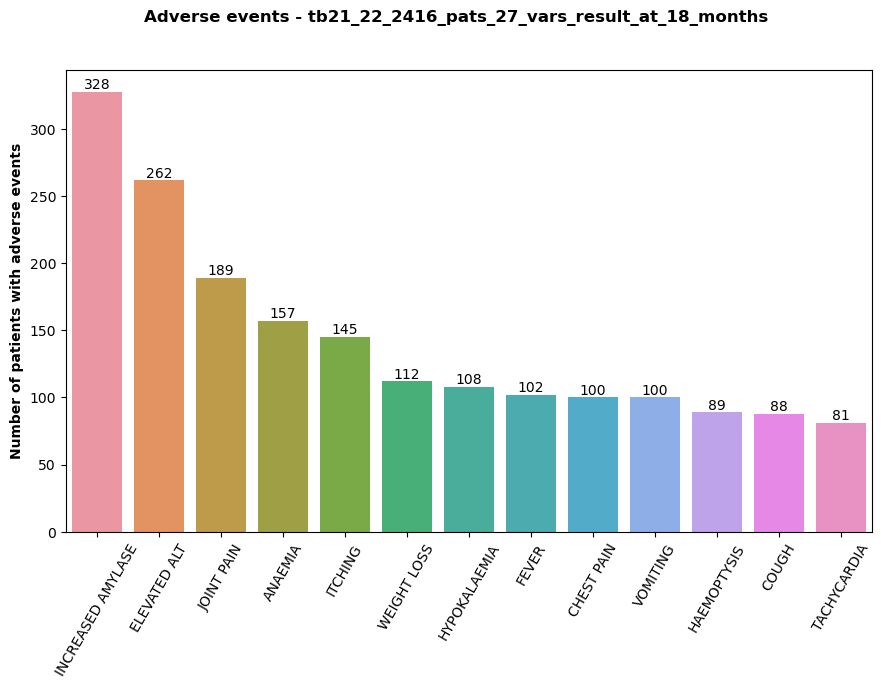

In [53]:
thr=80
for key in ae_dict.keys():
     
    plot_df=ae_dict[key][ae_dict[key]>thr].reset_index()
    fig,ax=plt.subplots(1,1,figsize=(len(plot_df)*0.8,6))
    fig.suptitle(f'Adverse events - {key}' ,fontweight='bold')
    #sns.barplot(ae_dict[key][ae_dict[key]>100],ax=ax)
    sns.barplot(data=plot_df,x='index',y=0)
    ax.set_ylabel('Number of patients with adverse events',fontweight='bold')
    ax.tick_params(axis='x',labelsize=10,labelrotation=60)
    ax.set_xticklabels([x.split('ae_')[-1] for x in (ae_dict[key][ae_dict[key]>thr]).index])
    ax.set_xlabel(None)
    for bars in ax.containers:
        ax.bar_label(bars,fontsize=10)

(0.0, 225.0)

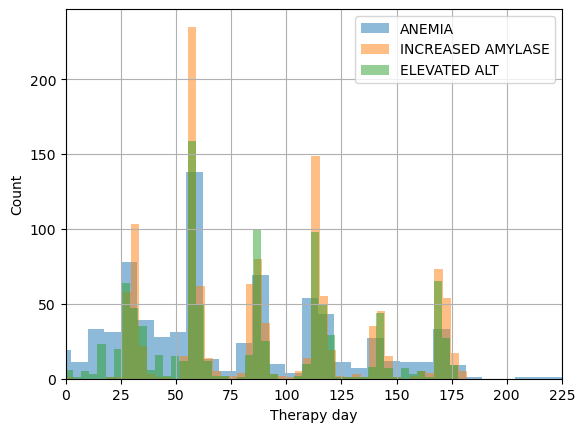

In [51]:
data.loc[data['ae_ANAEMIA']!=0,'DAY'].hist(bins=50,label='ANEMIA',alpha=0.5)
data.loc[data['ae_INCREASED AMYLASE']!=0,'DAY'].hist(bins=50,label='INCREASED AMYLASE',alpha=0.5)
data.loc[data['ae_ELEVATED ALT']!=0,'DAY'].hist(bins=50,label='ELEVATED ALT',alpha=0.5)
plt.legend()
plt.ylabel('Count')
plt.xlabel('Therapy day')
plt.xlim(0,225)

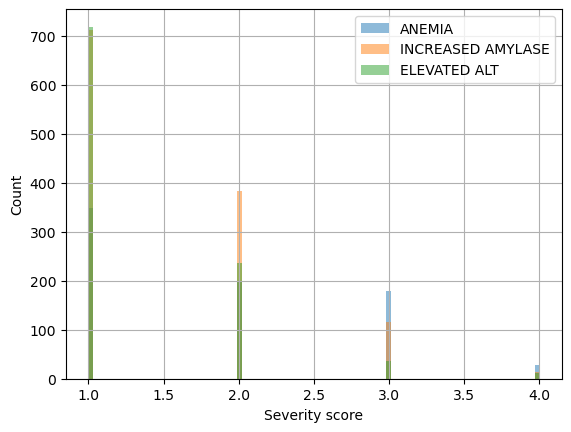

In [56]:
data.loc[data['ae_ANAEMIA']!=0,'ae_ANAEMIA'].hist(bins=100,label='ANEMIA',alpha=0.5)
data.loc[data['ae_INCREASED AMYLASE']!=0,'ae_INCREASED AMYLASE'].hist(bins=100,label='INCREASED AMYLASE',alpha=0.5)
data.loc[data['ae_ELEVATED ALT']!=0,'ae_ELEVATED ALT'].hist(bins=100,label='ELEVATED ALT',alpha=0.5)
plt.ylabel('Count')
plt.xlabel('Severity score')
plt.legend()

In [ ]:
%run s7_0_functions_for_data_preprocessing_for_ml.ipynb

In [ ]:
df=load_merged_data_of_lab_vars()

if (df.index.duplicated().any()):
    #df=df.drop(columns=[x for x in df.columns for y in ['STD_CAT_RESULT','STD_CAT_UNITS'] if y in x])
    print(df[df.index.duplicated(keep=False)])

In [ ]:
print(df.head(10))

In [ ]:
#data.columns[data.columns.str.startswith('ce')]

[coln for var in common_vars['RESULT_AT_18_MONTHS'] for coln in data.columns if coln.startswith(var)]

data.columns[:50]
#common_vars['RESULT_AT_18_MONTHS']
#common_pats={}

In [ ]:
data['lb_Blood Creatinine Clearance_STD_CAT_RESULT'].unique()

## Select columns

In [12]:
def load_merged_data_of_lab_vars():
    #load patient IDs who are considered in this  analysis
    pat_id_df=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
    # get all pat ids
    all_ids=pat_id_df['USUBJID'].to_list()

    fname='merged_df.csv.gz'
    
    fn=os.path.join('../data/',fname)
    merged_df=pd.read_csv(fn,low_memory=False,index_col=0)

    return merged_df


#### -----------------------------------
def subset_columns_relevant_for_analysis(data,pats_for_analysis,common_variables_for_analysis,return_selected_columns_only):
    # Read lab test variable type information (numerical or categorical)
    with open('../data/lab_variables.pkl', 'rb') as f:
        lab_variable_type_dict = pickle.load(f)
    
    ## Correct typos and drop some duplicated columns
    #data.columns = ['WEEK' if x=='Week' else x for x in data.columns]
    
    ### SELECT COLUMNS THAT HOLD THE RESULT INFROMATION USED IN THE ANALYSIS FOR EACH DATASET TYPE
    dataset_types_of_common_vars=list(set([x.split('_')[0] for x in common_variables_for_analysis if '_' in x]))

    result_column_names_per_dataset_type={  
                
                'mb':{'categorical':{'categorical_vars':['Identification','Culture Growth','Categorical Count','Unknown',\
                                                        'Colony Count, Categorical','MPT64 Antigen Test'],
                                    'categorical_result_suffix':['RESULT']},
                    'numerical':{'numerical_vars':['Time to Detection','Colony Count','Minimum Cycle Threshold of Detection'],
                                'numerical_result_suffix':['STD_NUM_RESULT','STD_NUM_UNITS']}},

                'pc':{'numerical':{'numerical_result_suffix':['STD_NUM_RESULT','STD_UNITS']}},

                're':{'categorical':{'categorical_vars':['Cavitation','X-Ray compatible with TB','Development of New Lesions',\
                                                        'Extension of Old Lesions','Extent of Disease','Interpretation',\
                                                        'Size Of Cavitation','Detailed Classification'],
                                    'categorical_result_suffix':['STD_CAT_RESULT']},
                    #'numerical':{'numerical_vars':['Detailed Classification'],
                    #            'numerical_result_suffix':['STD_NUM_RESULT']}
                                                                             },
        
                'vs':{'numerical':{'numerical_result_suffix':['STD_NUM_RESULT','VSSTRESU']}},

                'lb':{'categorical':{'categorical_vars':lab_variable_type_dict['lb_categorical_vars'],
                                    'categorical_result_suffix':['STD_CAT_ORDINAL_RESULT']},
                    'numerical':{'numerical_vars':lab_variable_type_dict['lb_numerical_vars'],
                                #'numerical_result_suffix':['STD_NUM_RESULT_SCALED']},
                                'numerical_result_suffix':['STD_NUM_RESULT','STD_NUM_UNIT']},
                                 },

                #'mh':{'categorical':{'categorical_result_suffix':}},

                'ce':{'categorical':{'categorical_result_suffix':['STD_CAT_RESULT','STD_CETOXGR']}},

                'mr':{'categorical':{'categorical_result_suffix':['STD_CAT_RESULT']}},

                'mic':{'numerical':{'numerical_result_suffix':['STD_NUM_RESULT','MSSTRESU']}},

                'ms':{'categorical':{'categorical_result_suffix':['STD_CAT_RESULT']},
                    'numerical':{'numerical_result_suffix':['SUSC_CONC','RESISTANCE_CONC']}},

                'su':{'categorical':{'categorical_result_suffix':['STD_CAT_RESULT']}}}

    ### Collect the columns to keep for analysis from the dataframe containing the previously selected variables
    columns_for_analysis={}

    ## Loop over the common variables among patients selected in previous step, and using the dictionary above
    #  extract the columns that hold usable result information for the analysis
    datasets_to_loop_over=set([*result_column_names_per_dataset_type])&set(dataset_types_of_common_vars)

    for dataset_type in datasets_to_loop_over:
        columns_for_analysis[dataset_type]=[]
        dataset_type_vars_all=[x for x in common_variables_for_analysis if x.startswith(dataset_type+'_')]
        
        for dataset_type_var in dataset_type_vars_all:
            stripped_dataset_type_var=dataset_type_var.split('_')[1]

            for var_type in result_column_names_per_dataset_type[dataset_type].keys():

                if var_type+'_vars' in result_column_names_per_dataset_type[dataset_type][var_type].keys():

                    if stripped_dataset_type_var in result_column_names_per_dataset_type[dataset_type][var_type][var_type+'_vars']:
                        for suffix in result_column_names_per_dataset_type[dataset_type][var_type][var_type+'_result_suffix']:
                            columns_for_analysis[dataset_type].append('_'.join([dataset_type_var,suffix]))

                elif var_type+'_vars' not in result_column_names_per_dataset_type[dataset_type][var_type].keys(): 
                    for suffix in result_column_names_per_dataset_type[dataset_type][var_type][var_type+'_result_suffix']:
                        columns_for_analysis[dataset_type].append('_'.join([dataset_type_var,suffix]))


    ## Extract column holding drug regimen cumulative dose information
    temporal_cols=data.columns[data.columns.str.startswith(('ae_','cmdos_','cmday_','cmind_','mh_','dr_reg_'))].tolist()

    ## Create one list of the columns_for_analysis dictionary values containing variables from the different dataset types
    columns_for_analysis_list=list(chain(*np.array(list(columns_for_analysis.values()),dtype=object)))

    ## Columns names of patients extracted from dm dataframe
    dm_colnames=['USUBJID','DAY','STUDYID','ARM','AGE','SEX']
    cols_for_analysis=dm_colnames+ columns_for_analysis_list + temporal_cols


    ## If return_columns_only -> select and return COLUMNS ONLY for analysis from the provided dataset
    if return_selected_columns_only==True:

        data_for_anal=data.loc[:,data.columns.isin(cols_for_analysis)]

        ## Drop mb columns, that are culture based and don't give an instant result,
        #  or the method is unknown -> KEEP MGIT MEASUREMENTS, AS THEY ARE THE GOAL OF PREDICTION
        #mb_cols_to_drop='|'.join(['mb_Culture Growth','mb_Categorical Count','mb_Colony Count','mb_Colony Count, Categorical','mb_Unknown'])
        cols_for_analysis=data_for_anal.columns
                
        return cols_for_analysis

    
    ## If return_columns_only is False -> select columns for analysis and return the DATASET with selected columns
    if return_selected_columns_only==False:
        # Drop all NaN columns and duplicates
        data_for_anal=data.loc[data['USUBJID'].isin(pats_for_analysis),cols_for_analysis].dropna(how='all',axis=1)

        ## Drop mb columns, that are culture based and don't give an instant result,
        #  or the method is unknown -> KEEP MGIT MEASUREMENTS, AS THEY ARE THE GOAL OF PREDICTION
        #mb_cols_to_drop='|'.join(['mb_Culture Growth','mb_Categorical Count','mb_Colony Count','mb_Colony Count, Categorical','mb_Unknown'])
        #data_for_anal=data_for_anal.loc[:,~data_for_anal.columns.str.contains(mb_cols_to_drop,na=False)]
        
        
        return data_for_anal



### -------------------------------------------------------
##  Add previously created temporal dataframes (__ae,cm,dr_reg__) + 
#   static medical history (__mh__) to __merged_df__ (dataframe containing previously merged laboratory variables)

def concatenate_temporal_data(pats_for_analysis,keep_data_with_unknown_drug_regimen,
                             common_variables_for_analysis,
                             keep_days_with_lab_measurements_only):
    from itertools import chain
    start = time.time()
    ## Load whole dataset
    all_phase_df=load_merged_data_of_lab_vars()
    
    ## Subset merged dataframe to patients who are considered for analysis
    df_for_anal=all_phase_df.loc[all_phase_df['USUBJID'].isin(pats_for_analysis),:]#.dropna(how='all',axis=1)
    end=time.time()
    t=round((end-start)/60,2)
    print('lab measurement data: done ',t, ' minutes')  
    print('dataframe shape: ',df_for_anal.shape)  

    
    ### LOOP OVER TEMPORAL DATASETS AND ADD THEM TO THE DATAFRAME CREATED IN PREVIOUS STEP

    temp_df_fnames={'dr_reg':'out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',
                    'ae_temp':'out_ae_standardised_temporal.csv.gz',
                    'cm_temp_drugs_doses':'out_cm_temporal_with_doses.csv.gz',
                    'cm_temp_drugs_days_of_appl':'out_cm_temporal_days_of_application.csv.gz',
                    'cm_temp_ind':'out_cm_temporal_indications.csv.gz'}                    

    
    for temp_df_name in [*temp_df_fnames][0:]:

        fn=os.path.join('../data',temp_df_fnames[temp_df_name])
        if temp_df_name=='dr_reg':
            temp_df=pd.read_csv(fn,low_memory=False,index_col=0)
            #print('dr_reg shape',temp_df.shape)

        ## For these dataframes the pre-selected variables can reduce the numbers of columns that need to be read
        #  Faster read-in time
        if temp_df_name=='ae_temp' or temp_df_name=='cm_temp_ind':
            data_for_cols=pd.read_csv(fn, index_col=0, nrows=0)
            cols_to_read=['DAY','USUBJID']+ list(set(common_variables_for_analysis)&set(data_for_cols.columns))
            temp_df=pd.read_csv(fn,low_memory=False,usecols=cols_to_read,index_col=0)
        
        ## The columns names of these are not in the pre-selected variables, as they are standardised and 
        #  derived in 3_4 -> read all of their columns and drop the unnecessary ones
        if temp_df_name=='cm_temp_drugs_doses' or temp_df_name=='cm_temp_drugs_days_of_appl':  
            temp_df=pd.read_csv(fn,low_memory=False,index_col=0)  


        common_idx=list(set(temp_df['USUBJID'])&set(df_for_anal['USUBJID']))
        temp_df=temp_df.loc[temp_df['USUBJID'].isin(common_idx)].dropna(how='all',axis=1)
        
        if temp_df_name=='dr_reg':
            cols_to_keep=temp_df.columns[temp_df.columns.str.contains('cumul',na=False)].tolist() + ['USUBJID','DAY','STUDYID']
            temp_df=temp_df.loc[temp_df['USUBJID'].isin(pats_for_analysis),cols_to_keep].fillna(0)
            dr_reg_max_days=temp_df.loc[:,['USUBJID','DAY']]
            
            ## KEEP ONLY THE DAYS THAT ARE PRESENT IN df_for_anal -> MERGE DATA ONLY FROM THOSE DAYS in dr_reg
            # i.e. Pat 1 has measurements from day 1, 14, 28, 56, 120, 155 in df_for_anal, whereas in dr_reg 
            #      Pat 1 has consecutive data from day 1-day 182 -> 
            #      to merge data from only the days present in df_for_anal, use 'left' as merging method
            if keep_days_with_lab_measurements_only==True:
                merge_method='left'
            
            # MERGE ON THE DAYS THAT ARE PRESENT IN dr_reg -> 
            # i.e. Pat 1 has measurements from day 1, 14, 28, 56, 120, 155 in df_for_anal, whereas in dr_reg 
            #      Pat 1 has consecutive data from day 1-day 182 -> merge an all days from day 1-182 ->
            #      for this use 'outer' as merging method
            if keep_days_with_lab_measurements_only==False:  
                merge_method='outer'

            df_for_anal=pd.merge(df_for_anal,temp_df,left_on=['USUBJID','DAY','STUDYID'],\
                                right_on=['USUBJID','DAY','STUDYID'],how=merge_method)                             

            if keep_data_with_unknown_drug_regimen==False:
                ## KEEP THERAPY RANGE ONLY, WHERE THERE IS RELIABLE DRUG REGIMEN DATA & MICROBIOLOGICAL MEASUREMENTS AVAILABLE
                comm_idx=list(set(dr_reg_max_days['USUBJID'])&set(df_for_anal['USUBJID']))
                days_to_drop=[]
                for pat in comm_idx[0:]:
                    dr_reg_max=(dr_reg_max_days[dr_reg_max_days['USUBJID']==pat]['DAY'].max())
                    #mb_max=(df_for_anal[(df_for_anal['USUBJID']==pat)&
                    #                ~(df_for_anal.loc[:,df_for_anal.columns.str.startswith('mb_')].isna().all(axis=1))]['DAY'].max())
                    max_day_to_keep=dr_reg_max #max(mb_max,dr_reg_max) # 
                    days_to_drop.append(df_for_anal[(df_for_anal['USUBJID']==pat)&(df_for_anal['DAY']>max_day_to_keep)].index.tolist())
                days_to_drop=list(chain(*days_to_drop))
                df_for_anal=df_for_anal.drop(index=days_to_drop)                                  
            

        if temp_df_name!='dr_reg':                
            df_for_anal=pd.merge(df_for_anal,temp_df,left_on=['USUBJID','DAY','STUDYID'],\
                                    right_on=['USUBJID','DAY','STUDYID'],how='left')
        
        del temp_df
        end=time.time()
        t=round((end-start)/60,2)
        print(temp_df_name+' done ',t, ' minutes')  
        print('dataframe shape: ',df_for_anal.shape) 
             

    
    ###--------------------
    #### LOAD EXPANDED MEDICAL HISTORY DATAFRAME AND ADD COLUMNS FOR EACH PATIENT 
    mh=pd.read_csv('../data/out_mh_standardised_expanded.csv.gz',low_memory=False,index_col=0)
    ## Drop terms with less than 10 patients having that term in medical history
    mh=mh.loc[:,~mh.columns.str.contains('STUDYID')]
    #mh=mh.loc[:,mh.sum()>10]
    
    common_idx=list(set(mh.index)&set(df_for_anal['USUBJID']))
    mh=mh.loc[common_idx,:].dropna(how='all',axis=1)

    mh_colnames_with_prefix=['mh_'+x for x in mh.columns.tolist()]
    mh.columns=mh_colnames_with_prefix
    common_cols=list(set(mh.columns)&set(common_variables_for_analysis))
    mh=mh.loc[:,common_cols]
    #mh=mh.rename_axis('USUBJID').reset_index()

    #df_for_anal=df_for_anal.merge(mh,on=['USUBJID'])
    for pat_id in common_idx:

        df_for_anal.loc[df_for_anal['USUBJID']==pat_id,common_cols]=mh.loc[pat_id,:].values
    del mh        
    #df_for_anal=df_for_anal.drop(columns=['mh_STUDYID'])

    end=time.time()
    t=round((end-start)/60,2)
    print('mh done ',t, ' minutes')
    print('dataframe shape: ',df_for_anal.shape) 
    
    
    ### Fill NaN datapoints with 0 where no imputation is needed 
    #  (cmdos and cmday columns need forward fill as they are cumulative doses/days of drug application)
    #df_for_anal=df_for_anal.sparse.to_dense()
    df_for_anal.loc[:,df_for_anal.columns.str.startswith(('ae_','cmind_','mh_'))]=df_for_anal.loc[:,df_for_anal.columns.str.startswith(('ae_','cmind_','mh_'))].fillna(0)

    end=time.time()
    t=round((end-start)/60,2)
    print('fillna with 0s done ',t, ' minutes') 
       
    return df_for_anal

### -------------------------------------------------------
## Return all the variable names in the formats:
#  1. As a dict, where each key corresponds to one dataset type and the values are all the variables for that datset type
#      i.e. {'lb':['lb_Blood Hemoglobin','lb_Blood Urate',...], 'mb':['mb_Time to Detection',...],...}
#  2. As a list containing all the variable names
#     i.e. ['lb_Blood Hemoglobin','lb_Blood Urate',...,'mb_Time to Detection'...,]
def get_all_var_names():
    f = open('../data/all_pat_variables_with_reliable_therapy_data_dict',"rb")
    d=pickle.load(f)

    vars_per_dataset={}
    all_vars=set()
    for ds_type in [*d]:
        l=[]
        for pat in d[ds_type]:
            l.append(d[ds_type][pat])    
        
        unique_elements = set()
    
        # Loop through each sub-list in the ragged list
        for sublist in l:
            # Add each element to the set
            unique_elements.update(sublist)

        ## Update the dict subsetted per dataset type
        vars_per_dataset[ds_type]=unique_elements
        
        ## Update set containing all variable names
        all_vars.update(unique_elements)
        #print(unique_elements)    
    
    return vars_per_dataset,list(all_vars)



#### =======================
### LOAD COMMON VARIABLES AND PATIENTS FOR THE GIVEN OUTPUT LABEL CATEGORY, CREATED IN S7_2_....IPNYB NOTEBOOK
def return_common_vars_pats_for_anal(result_cat,selection_method,num_of_common_vars,clust_comb,graph_metric): 

    ## Select the common variables and common patients
    if 'clustering' in selection_method:
        if selection_method=='patient_clustering':
            fname='pat_clust_common_vars.pickle'
        if selection_method=='var_clustering':
            fname='var_clust_common_vars.pickle'
        
        ## Use patients graphs to extract common patients and variables
        fn=os.path.join('../data/',fname)
        with open(fn, 'rb') as f:
            common_vars=pickle.load(f)
        
        common_variables_for_analysis=common_vars[result_cat][clust_comb][num_of_common_vars]['common_variables']+['USUBJID','DAY']
        pats_for_analysis=common_vars[result_cat][clust_comb][num_of_common_vars]['patients']
    
    if 'graph' in selection_method:
        if selection_method=='patient_graph':
            fname='pat_gr_common_dict.pickle'
        
        if selection_method=='variable_graph':
            fname='var_gr_common_dict.pickle'  

        ## Use patients graphs to extract common patients and variables
        fn=os.path.join('../data/',fname)
        with open(fn, 'rb') as f:
            gr_common_dict=pickle.load(f)
        num_of_pats=[*gr_common_dict[result_cat][clust_comb][graph_metric][num_of_common_vars]][0]
        common_variables_for_analysis=gr_common_dict[clust_comb][graph_metric][num_of_common_vars][num_of_pats]['common_vars']+['USUBJID','DAY']
        common_variables_for_analysis=list(set(common_variables_for_analysis))
        pats_for_analysis=gr_common_dict[clust_comb][graph_metric][num_of_common_vars][num_of_pats]['common_pats']
  
    return common_variables_for_analysis,pats_for_analysis


#data=load_merged_data_of_lab_vars()
#data.columns=data.columns.str.replace("STD_NUM_UNITS", "STD_NUM_UNIT", regex=True)



keep_data_with_unknown_drug_regimen=False
keep_days_with_lab_measurements_only=True

variables_to_load='all'

for key in [*parameters_for_analysis][:1]:
    print(key)
    parameter_dict=parameters_for_analysis[key]
    result_cat=parameter_dict['result_cat']
    selection_method=parameter_dict['selection_method']
    clust_comb=parameter_dict['clust_comb']
    num_of_common_vars=parameter_dict['num_of_common_vars']
    graph_metric=parameter_dict['graph_metric']


    print('selection method: ',key)
    common_variables_for_analysis,pats_for_analysis = return_common_vars_pats_for_anal(result_cat,selection_method,
                                                                                      num_of_common_vars,clust_comb,
                                                                                      graph_metric)
    print(len(pats_for_analysis))

    ## To subset the "measured" variables to the PRE-SELECTED COMMON VARS ACROSS PATIENTS in s7_2.notebook 
    #  (here stored as "num_of_common_vars" variable) => run select_columns_for_analysis
    if variables_to_load=='pre-selected':
        variables_for_analysis=common_variables_for_analysis

    ## To select ALL MEASURED variables that were measured in the analysis time period, run get_all_var_names
    if variables_to_load=='all':
        _,all_vars=get_all_var_names()
        variables_for_analysis=all_vars
    
    
    data_conc = concatenate_temporal_data(pats_for_analysis,keep_data_with_unknown_drug_regimen,
                                         variables_for_analysis,
                                         keep_days_with_lab_measurements_only)
    
    data_conc = subset_columns_relevant_for_analysis(data_conc,pats_for_analysis,all_vars,return_selected_columns_only=True)
    
    fn='../data/'+key+'_all_data_concat.csv.gz'
    data_conc.to_csv(fn,compression='gzip')
    #del data_conc

tb21_22_2416_pats_27_vars_result_at_18_months
selection method:  tb21_22_2416_pats_27_vars_result_at_18_months
2416


NameError: name 'df' is not defined

In [8]:
data_conc['USUBJID'].unique().shape

(2416,)

In [293]:
data=load_merged_data_of_lab_vars()
df_for_anal=data.loc[data['USUBJID'].isin(pats_for_analysis),:]
df_for_anal.shape

(24897, 941)

In [285]:
data.loc[data['USUBJID']=='TB-1020/1016',:]

USUBJID   DAY  STUDYID  mb_Categorical Count_STD_NUM_UNIT  \
0      TB-1020/1016   1.0  TB-1020                                NaN   
1      TB-1020/1016  90.0  TB-1020                                NaN   
67007  TB-1020/1016   NaN  TB-1020                                NaN   
68882  TB-1020/1016  -1.0  TB-1020                                NaN   

       mb_Categorical Count_STD_NUM_RESULT mb_Categorical Count_RESULT  \
0                                      NaN                    negative   
1                                      NaN                    negative   
67007                                  NaN                         NaN   
68882                                  NaN                         NaN   

       mb_Culture Growth_STD_NUM_UNIT  mb_Culture Growth_STD_NUM_RESULT  \
0                                 NaN                               NaN   
1                                 NaN                               NaN   
67007                             NaN                               NaN   
68882                             NaN                               NaN   

      mb_Culture Growth_RESULT  mb_Identification_STD_NUM_UNIT  ...  \
0                     negative                             NaN  ...   
1                     negative                             NaN  ...   
67007                      NaN                             NaN  ...   
68882                      NaN                             NaN  ...   

       ms_Gatifloxacin_STD_CAT_RESULT ms_Gatifloxacin_RESISTANCE_CONC  \
0                                 NaN                             NaN   
1                                 NaN                             NaN   
67007                             NaN                             NaN   
68882                             NaN                             NaN   

      ms_Gatifloxacin_SUSC_CONC  ms_Gatifloxacin_STD_CAT_ORDINAL_RESULT  \
0                           NaN                                     NaN   
1                           NaN                                     NaN   
67007                       NaN                                     NaN   
68882                       NaN                                     NaN   

      su_SMOKING EVER_STD_CAT_RESULT  su_SMOKING EVER_STD_CAT_ORDINAL_RESULT  \
0                                  N                                     0.0   
1                                NaN                                     NaN   
67007                            NaN                                     NaN   
68882                            NaN                                     NaN   

        AGE SEX                       RACE  \
0      24.0   F  BLACK OR AFRICAN AMERICAN   
1      24.0   F  BLACK OR AFRICAN AMERICAN   
67007  24.0   F  BLACK OR AFRICAN AMERICAN   
68882  24.0   F  BLACK OR AFRICAN AMERICAN   

                                                     ARM  
0      Study Regimen 2: 2 months of daily ethambutol,...  
1      Study Regimen 2: 2 months of daily ethambutol,...  
67007  Study Regimen 2: 2 months of daily ethambutol,...  
68882  Study Regimen 2: 2 months of daily ethambutol,...  

[4 rows x 941 columns]

In [10]:
print(data_conc.loc[data_conc['USUBJID']=='TB-1020/1016',variables_for_analysis].groupby('USUBJID').apply(lambda x: x.nunique(dropna=True)))

KeyError: '[\'cm_CALCIUM CARBONATE\', \'cm_NAPROXEN\', \'mh_LEFT LEG WEAKNESS\', \'mh_EMPERIC TREATMENT FOR TB\', \'ae_HYPEGLYCAEMIA\', \'cm_ALUMINUM HYDROXIDE\', \'mh_BROAD SPECTRUM ANTIBIOTIC\', \'cm_HESPERIDIN\', \'mh_FUNGAL RASH ABDOMEN, CHEST, AND BACK\', \'cmind_PAINFUL RIGHT SIDE OF THE NECK\', \'ae_THIOMBOCYTOPENIA\', \'mh_RIGHT EYE SIGHT POOR\', \'cmind_LEFT EYELID SWOLLEN SECOND TO INSECT BITE\', \'cmind_FOR NAUSEA AND VOMITTING\', \'ae_LEFT ANKLE SOFT TISSUE INJURY\', \'ae_LYMPHOPENIA\', \'ae_PAINFUL(RIGHT)GLENOHUMERAL JOINT (RIGHT)SHOULDER\', \'ae_ENLARGED EPITROCHLEAR LYMPHNODES BILATERAL\', \'ae_GENITAL CANDIDIASIS\', \'cmind_FAECAL IMPACTION\', \'mh_SMALL POX\', \'cm_ARTESUNATE\', \'ms_Ofloxacin\', \'cm_CHLORAMPHENICOL\', \'ae_ACUTE TRANSVERSE MYELITIS\', \'ae_SWELLING OF RIGHT HAND AND FINGERS\', \'ae_DYSMENNORHEE\', \'cmind_TRAUMATIC JOINT RIGHT BIG TOE\', \'mh_FINGER NODULES\', \'cm_OMEPRAZOLE\', \'cmind_EPIGASTRIA BURNING AND LOWER CHEST BURNING\', \'cmind_KERATOCONJ

In [250]:
len(all_vars)

4731